In [ ]:
import numpy as np
import matplotlib.pyplot as plt


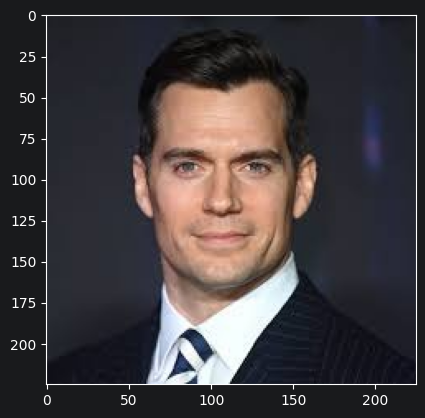

In [ ]:
from PIL import Image
import numpy as np

img_pil = Image.open('image2.jpg')  # change filename
img_rgb = np.array(img_pil)
img_arr = img_rgb.copy()
plt.imshow(img_arr)

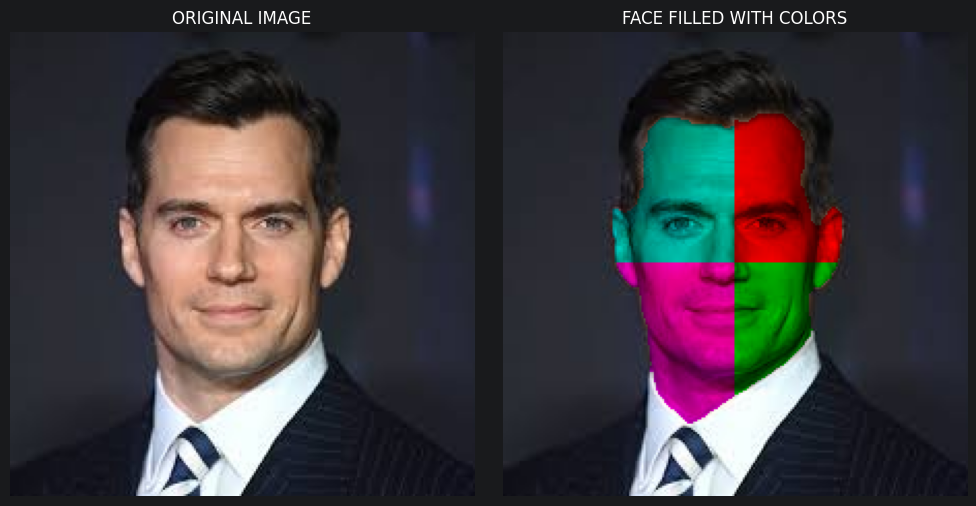

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image2.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_arr = img_rgb.copy()

# GrabCut for face segmentation - no mediapipe needed!
mask = np.zeros(img.shape[:2], np.uint8)
bgd = np.zeros((1,65), np.float64)
fgd = np.zeros((1,65), np.float64)

h, w = img.shape[:2]
rect = (w//6, h//8, w*4//6, h*6//8)  # face region rectangle

cv2.grabCut(img, mask, rect, bgd, fgd, 5, cv2.GC_INIT_WITH_RECT)
face_mask = np.where((mask==2)|(mask==0), 0, 1).astype(bool)

mid_h, mid_w = h//2, w//2

rows = np.arange(h)[:,None]
cols = np.arange(w)[None,:]

# Top-Left → Cyan
mask_tl = face_mask & (rows < mid_h) & (cols < mid_w)
img_arr[mask_tl, 0] = 0

# Top-Right → Red
mask_tr = face_mask & (rows < mid_h) & (cols >= mid_w)
img_arr[mask_tr, 1] = 0
img_arr[mask_tr, 2] = 0

# Bottom-Left → Magenta
mask_bl = face_mask & (rows >= mid_h) & (cols < mid_w)
img_arr[mask_bl, 1] = 0

# Bottom-Right → Green
mask_br = face_mask & (rows >= mid_h) & (cols >= mid_w)
img_arr[mask_br, 0] = 0
img_arr[mask_br, 2] = 0

fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(img_rgb)
axes[0].set_title("ORIGINAL IMAGE")
axes[0].axis('off')
axes[1].imshow(img_arr)
axes[1].set_title("FACE FILLED WITH COLORS")
axes[1].axis('off')
plt.tight_layout()
plt.show()
img = Image.fromarray(img_arr.astype(np.uint8))
img.save('output_image_.png')